In [1]:
import os
import sys
import glob
import numpy as np

sys.path.append('/om2/user/jmhicks/projects/TextureStreaming/code/')

from chexture_choolbox.auditorytexture.statistics_sets import (
    STAT_SET_FULL_MCDERMOTTSIMONCELLI as statistics_dict
)
from chexture_choolbox.auditorytexture.texture_model import TextureModel
from chexture_choolbox.auditorytexture.helpers import FlattenStats
from texture_prior.params import model_params as model_params_tm
from texture_prior.params import statistics_set, texture_dataset
from texture_prior.utils import path


sys.path.append("/om2/user/bjmedina/auditory-memory/memory/")
sys.path.append('/om2/user/bjmedina/auditory-memory/memory/src/model/')
sys.path.append('/om2/user/bjmedina/auditory-memory/memory/utls/')
import encoders
import ScoreFunction

from utls.loading import load_results, load_results_with_isi0_exclusion, load_results_with_isi0_dprime_exclusion, move_sequences_to_used, load_results_with_exclusion
from utls.dprime import recompute_dprime_by_isi_per_subject
from utls.reliability import compute_itemwise_split_half_reliability
from utls.plotting import plot_dprime_by_isi, plot_itemwise_split_half_scatter_df, ensure_dir

from utls.reliability import compute_power_curve
from utls.plotting import plot_power_curve

device = 'cuda'

sf = ScoreFunction.ScoreFunction(config="/om2/user/bjmedina/auditory-memory/memory/assets/textures_diffusion2D_noVarScale_pc256_contrastive.yaml",
                                    device = device)


def plot_groupwise_item_response_scatter(
    results,
    title="Group-wise Item Responses",
    kind="hits",
    seed=42,
    split_method="half",
    save_path=None
):
    """
    Plots a scatter plot of itemwise response rates between two internally split groups.

    Args:
        df (pd.DataFrame): itemwise response matrix (participants x items)
        title (str): plot title
        kind (str): 'hits' or 'false_alarms' for axis labeling
        seed (int): random seed for reproducibility
        split_method (str): 'half' (default) or 'random' to determine splitting method
    """

    r = results['split_half_reliability'][kind][0]

    df = results['itemwise_responses'][kind]
    import matplotlib.pyplot as plt
    if df.shape[0] < 2:
        raise ValueError("DataFrame must have at least 2 participants to split.")

    np.random.seed(seed)

    n = len(df)
    indices = np.arange(n)

    if split_method == "random":
        np.random.shuffle(indices)

    mid = n // 2
    group1_df = df.iloc[indices[:mid]]
    group2_df = df.iloc[indices[mid:]]

    # Ensure columns are aligned
    common_items = sorted(set(group1_df.columns) & set(group2_df.columns))
    if not common_items:
        raise ValueError("No overlapping items between groups.")

    g1_means = group1_df[common_items].mean(axis=0)
    g2_means = group2_df[common_items].mean(axis=0)

    plt.figure(figsize=(6, 6))
    color = "green" if kind == "hits" else "red"
    plt.scatter(g1_means, g2_means, alpha=0.7, color=color, edgecolor="k")

    # Identity line
    lims = [0, 1]
    plt.plot(lims, lims, "--", color="gray", linewidth=1)

    # Optional: correlation
    plt.text(0.05, 0.9, f"r = {r:.2f}", transform=plt.gca().transAxes)

    plt.axis('square')
    plt.xlabel(f"Group 1 {kind} rate")
    plt.ylabel(f"Group 2 {kind} rate")
    plt.title(title)
    plt.xlim(lims)
    plt.ylim(lims)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300)
        plt.close()
    else:
        plt.show()

def compute_likelihood(score_model, input_stats, ckpt):
    """Computing the actual "prior" value
    If the score function can be treated as the vector field govering the temporal evolution
    of $x_t$ then we can integrate the ODE and apply a change of basis to evaluate the prior
    """
    score_model.load_state_dict(torch.load(ckpt))
    input_stats = input_stats.to(device)

    _, bpd = ode_likelihood(input_stats, score_model, marginal_prob_std_fn,
                            diffusion_coeff_fn,
                            input_stats.shape[0], device=device, eps=1e-5)
    
    return bpd

def parse(d):
  x = SimpleNamespace()
  _ = [setattr(x, k, parse(v)) if isinstance(v, dict) else setattr(x, k, v) for k, v in d.items() ]    
  return x

In [2]:
sounds_list = glob.glob("/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_atexts_2025/*wav")
pc_dims = 256
pc_texture_model = encoders.AudioTextureEncoderPCA(
    statistics_dict=statistics_set.statistics,
    pc_dims=pc_dims,
    model_params=model_params_tm,
    sr=20000,
    rms_level=0.1,
    duration=2.0,
    device=device
)

ALL_SOUNDS = glob.glob("/om2/data/public/audioset/wavs/unbalanced_train_segments_downloads/unbalanced_train_segments_downloads_*/*wav")
zscore_projector = encoders.ZScoreSpace(pc_texture_model, device=device)
zscore_projector.fit(sounds_list)

test_sounds_list = glob.glob("/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_atexts_2025/*wav")


In [3]:
# results = set(glob.glob("/mindhive/mcdermott/www/bjmedina/experiments/bolivia_2025/results/isi_16/ind-nature-len120/*csv"))
# results = list(results)

tasks = ["ind-nature-len120" ,"global-music-len120", "atexts-len120", "nhs-region-len120"]
which_task = tasks[1] # "global-music-len120", "atexts-len120" "nhs-region-len120"
base_path = "/mindhive/mcdermott/www/mturk_stimuli/bjmedina/{}/sequences/isi_16/len120/"
seqs_paths = {"ind-nature-len120": "mem_exp_ind-nature_2025", 
              "global-music-len120": "global-music-2025-n_80",
              "atexts-len120": "mem_exp_atexts_2025",
              "nhs-region-len120": "nhs-region-n_80"}


hr_task_name = {"ind-nature-len120": "Industrial and Nature", 
              "global-music-len120": "Globalized Music",
              "atexts-len120": "Auditory Textures",
              "nhs-region-len120": " 'Natural History of Song' "}

exps, seqs, fnames = load_results_with_exclusion(f"/mindhive/mcdermott/www/bjmedina/experiments/bolivia_2025/results/isi_16/{which_task}",
                                                    min_dprime=2,
                                                    min_trials=120,
                                                    skip_len60=True,
                                                    verbose=False,
                                                    return_skipped=False)



move_sequences_to_used(base_path.format(seqs_paths[which_task]), seqs)

print("Number of participants used in analysis:", len(exps))


safe_name = which_task.lower().replace(" ", "_")  # e.g., "globalized_music"
save_dir = os.path.join("/om2/user/bjmedina/auditory-memory/memory/figures/human-results/isi-16-only", safe_name)

ensure_dir(save_dir)
print(save_dir)

7k42cs6ga.csv] d' = 4.56 (HR=0.80, FAR=0.00)
[uz4y2ag389l.csv] d' = 0.00 (HR=0.40, FAR=0.40)
[765x4b7uveg.csv] d' = 4.56 (HR=1.00, FAR=0.20)
[ksx9vft3sql.csv] d' = 3.47 (HR=0.40, FAR=0.00)
[83djojqtzr3.csv] d' = 3.47 (HR=1.00, FAR=0.60)
[pcyudgbxj93.csv] d' = 4.56 (HR=1.00, FAR=0.20)
[tzbkuehr9z8.csv] d' = 7.44 (HR=1.00, FAR=0.00)
[9jjntr8qw9v.csv] d' = 2.88 (HR=1.00, FAR=0.80)
[bxp5omnl5xp.csv] d' = 7.44 (HR=1.00, FAR=0.00)
[3fo43rdabtw.csv] d' = -0.59 (HR=0.60, FAR=0.80)
[217q0jy6y1m.csv] d' = 7.44 (HR=1.00, FAR=0.00)
[115ppyved7q.csv] d' = 7.44 (HR=1.00, FAR=0.00)
[g78sladlyjx.csv] d' = 3.97 (HR=1.00, FAR=0.40)
[6pqoddou0mt.csv] d' = 4.56 (HR=1.00, FAR=0.20)
[efkvm122kj1.csv] d' = 7.44 (HR=1.00, FAR=0.00)
[61gl7674hq2.csv] d' = 3.97 (HR=1.00, FAR=0.40)
[4eajwh32uuc.csv] d' = 3.97 (HR=1.00, FAR=0.40)
[xh4w9vwgd2l.csv] d' = 7.44 (HR=1.00, FAR=0.00)
[mh0g5ph9ymp.csv] d' = 4.56 (HR=1.00, FAR=0.20)
[rt2kl5ofv7h.csv] d' = 0.00 (HR=0.40, FAR=0.40)
[y96kt5p42va.csv] d' = 3.97 (HR=1.00, FAR=

In [4]:
x = recompute_dprime_by_isi_per_subject(exps)
# Assuming `x` is your DataFrame
valid_isi_values = [-1, 0, 16]
x_filtered = x[x['isi'].isin(valid_isi_values)].copy()
x = x_filtered
print(x_filtered)#print(*sorted(seqs), sep="\n")

     subject  isi  hits  false_alarms  n_signal  n_noise  hit_rate   fa_rate  \
0          0   -1     0            27         0       75       NaN  0.360000   
1          0    0     5            27         5       75  1.000000  0.360000   
2          0   16    16            27        18       75  0.888889  0.360000   
3          1   -1     0            24         0       75       NaN  0.320000   
4          1    0     5            24         5       75  1.000000  0.320000   
..       ...  ...   ...           ...       ...      ...       ...       ...   
192       63    0     5            11         5       75  1.000000  0.146667   
193       63   16     6            11         9       75  0.666667  0.146667   
194       64   -1     0            36         0       75       NaN  0.480000   
195       64    0     5            36         5       75  1.000000  0.480000   
197       64   16    25            36        28       75  0.892857  0.480000   

      d_prime  
0         NaN  
1    4.

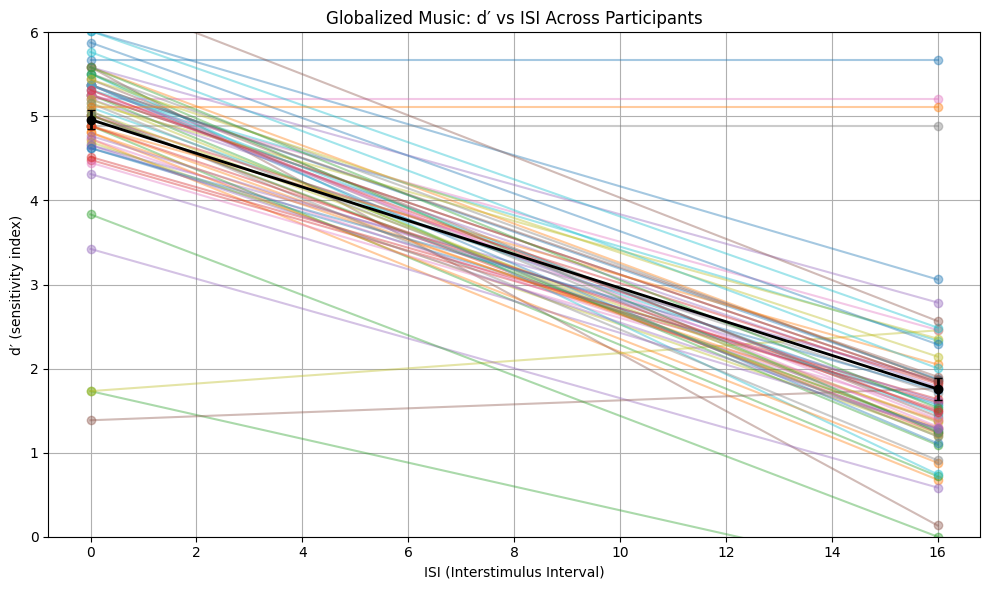

In [5]:
isi_plot_dir = os.path.join(save_dir, "dprime-vs-isi.png")

#plot_dprime_by_isi(x, stimulus_set=hr_task_name[which_task], save_path=isi_plot_dir);
plot_dprime_by_isi(x, stimulus_set=hr_task_name[which_task])#, save_path=isi_plot_dir)

In [6]:
# Only consider repeat trials with ISI >= 16
results_long = compute_itemwise_split_half_reliability(exps, min_isi=16, max_isi=16)
hits = results_long['itemwise_responses']['hits']
false_alarms  = results_long['itemwise_responses']['false_alarms']

# Optional coloring
label_hits_fa = {item: 'hit' for item in hits.columns}
label_hits_fa.update({item: 'fa' for item in false_alarms.columns})

print(results_long['split_half_reliability'])
print(f"[DEBUG] Final signal df shape: {hits.shape}")
print(f"[DEBUG] Final noise df shape: {false_alarms.shape}")
print(f"[DEBUG] Columns (signal items): {hits.columns[:5].tolist()}...")
print(f"[DEBUG] Columns (noise items): {false_alarms.columns[:5].tolist()}...")
# results_short = compute_itemwise_split_half_reliability(exps, min_isi=0, max_isi=16)
# signal_df = results_short['itemwise_responses']['hits']
# noise_df  = results_short['itemwise_responses']['false_alarms']

# # Optional coloring
# label_hits_fa = {item: 'hit' for item in signal_df.columns}
# label_hits_fa.update({item: 'fa' for item in noise_df.columns})

# print(results_short['split_half_reliability'])
# print(f"[DEBUG] Final signal df shape: {signal_df.shape}")
# print(f"[DEBUG] Final noise df shape: {noise_df.shape}")
# print(f"[DEBUG] Columns (signal items): {signal_df.columns[:5].tolist()}...")
# print(f"[DEBUG] Columns (noise items): {noise_df.columns[:5].tolist()}...")

{'hits': (0.5633215612700955, 0.060333385414620584), 'false_alarms': (0.7175516628155694, 0.0402596025703076)}
[DEBUG] Final signal df shape: (65, 80)
[DEBUG] Final noise df shape: (65, 80)
[DEBUG] Columns (signal items): ['mem_stim_0.wav', 'mem_stim_1.wav', 'mem_stim_10.wav', 'mem_stim_11.wav', 'mem_stim_12.wav']...
[DEBUG] Columns (noise items): ['mem_stim_0.wav', 'mem_stim_1.wav', 'mem_stim_10.wav', 'mem_stim_11.wav', 'mem_stim_12.wav']...


In [9]:
hr_cons_plot_dir = os.path.join(save_dir, "hit-rate-consistency.png")
far_cons_plot_dir = os.path.join(save_dir, "false-alarm-rate-consistency.png")

# Split groups (rows are participants)
plot_groupwise_item_response_scatter(results_long, kind="hits", save_path=hr_cons_plot_dir)
plot_groupwise_item_response_scatter(results_long, kind="false_alarms", save_path=far_cons_plot_dir)

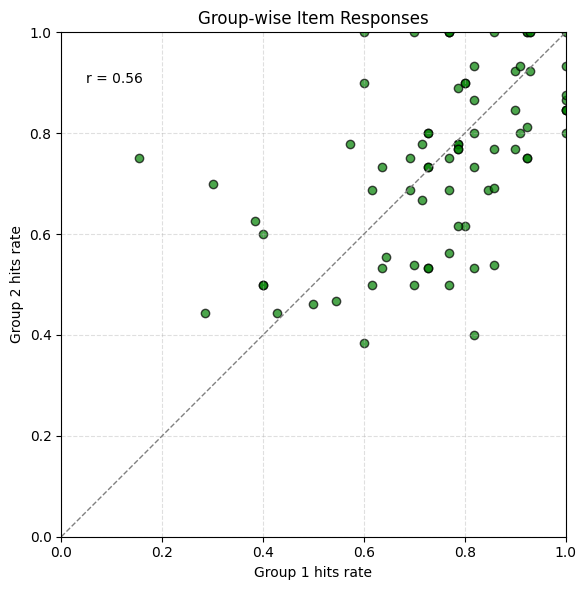

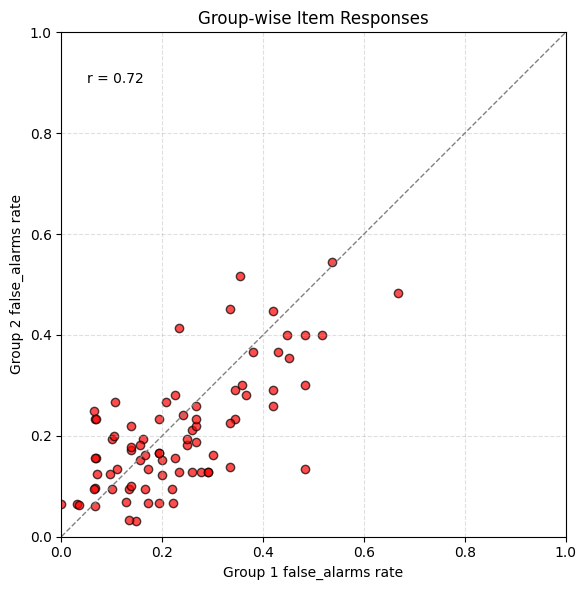

In [10]:
plot_groupwise_item_response_scatter(results_long, kind="hits")#, save_path=hr_cons_plot_dir)
plot_groupwise_item_response_scatter(results_long, kind="false_alarms")#, save_path=far_cons_plot_dir)

In [9]:
false_alarms["mem_stim_0.wav"].mean(axis=0)

0.6333333333333333

In [11]:
stim_fas = [false_alarms[stim].mean(axis=0) for stim in false_alarms.columns.tolist()]
stim_nlls = [sf.score_model(zscore_projector(stim)) for stim in false_alarms.columns.tolist()]

Skipping mem_stim_0.wav: [Errno 2] No such file or directory: 'mem_stim_0.wav'


TypeError: ScoreNetAudioV2.forward() missing 1 required positional argument: 't'